**Imports**

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torchvision.transforms as transforms
import os
import torchvision.models as models

**prepare data**

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR    = '/kaggle/input/datasets/jacobryan1234567/scrambled-piggies'
RGB_DIR     = os.path.join(DATA_DIR, 'RGB')
IR_DIR      = os.path.join(DATA_DIR, 'IR')
LABELS_PATH = os.path.join(DATA_DIR, 'labels.csv')

# ── Load & inspect ────────────────────────────────────────────────────────────
labels_df = pd.read_csv(LABELS_PATH)
print(f"Total samples: {len(labels_df)}")

print("\nLabel distribution:")
label_names = {-1: "cold", 0: "neutral", 1: "hot"}
for label in sorted(labels_df['label'].unique()):
    count = (labels_df['label'] == label).sum()
    print(f"  {label_names[label]:8s} ({label:2d}): {count:4d} images ({count/len(labels_df)*100:.1f}%)")

print("\nFold distribution:")
for fold in sorted(labels_df['fold'].unique()):
    fdf   = labels_df[labels_df['fold'] == fold]
    weeks = sorted(fdf['week'].unique())
    print(f"  Fold {fold}  weeks={weeks}  n={len(fdf)}")

Total samples: 4993

Label distribution:
  cold     (-1): 1699 images (34.0%)
  neutral  ( 0): 1514 images (30.3%)
  hot      ( 1): 1780 images (35.6%)

Fold distribution:
  Fold 1  weeks=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  n=999
  Fold 2  weeks=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  n=999
  Fold 3  weeks=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  n=999
  Fold 4  weeks=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  n=998
  Fold 5  weeks=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]  n=998


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# DATASET CLASS
# ═══════════════════════════════════════════════════════════════════════════
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import os
import torch

class PigStressDataset(Dataset):
    def __init__(self, df, rgb_dir, ir_dir, rgb_transform=None, ir_transform=None, augment=False):
        """
        Args:
            df: DataFrame with columns ['id', 'label', 'fold', 'week']
            rgb_dir: Path to RGB images directory
            ir_dir: Path to IR images directory
            rgb_transform: Transform for RGB images
            ir_transform: Transform for IR images
            augment: Whether to apply spatial augmentation (random flip/crop)
        """
        self.df = df.reset_index(drop=True)
        self.rgb_dir = rgb_dir
        self.ir_dir = ir_dir
        self.rgb_transform = rgb_transform
        self.ir_transform = ir_transform
        self.augment = augment
        
        # Map labels: -1→0 (cold), 0→1 (neutral), 1→2 (hot)
        self.label_map = {-1: 0, 0: 1, 1: 2}
        
        # Spatial augmentation (applied to both RGB and IR identically)
        if augment:
            self.spatial_aug = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(15),
            ])
        else:
            self.spatial_aug = None
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Get image id and construct paths: RGB/{id}.jpg and IR/{id}.jpg
        image_id = row['id']
        rgb_path = os.path.join(self.rgb_dir, f"{image_id}.jpg")
        ir_path = os.path.join(self.ir_dir, f"{image_id}.jpg")
        
        # Load images
        rgb_img = Image.open(rgb_path).convert('RGB')
        ir_img = Image.open(ir_path).convert('L')  # Grayscale for IR
        
        # Apply spatial augmentation to both (if enabled)
        if self.spatial_aug is not None:
            # Use same random seed for both images so transforms match
            seed = torch.randint(0, 2**32, (1,)).item()
            
            torch.manual_seed(seed)
            rgb_img = self.spatial_aug(rgb_img)
            
            torch.manual_seed(seed)
            ir_img = self.spatial_aug(ir_img)
        
        # Apply color/intensity transforms
        if self.rgb_transform:
            rgb_img = self.rgb_transform(rgb_img)
        if self.ir_transform:
            ir_img = self.ir_transform(ir_img)
        
        # Get label and map it
        label = self.label_map[row['label']]
        
        return rgb_img, ir_img, label


# ═══════════════════════════════════════════════════════════════════════════
# TRANSFORMS
# ═══════════════════════════════════════════════════════════════════════════

# Training transforms (with color augmentation for RGB only)
train_rgb_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_ir_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # No color augmentation for thermal!
])

# Validation transforms (no augmentation)
val_rgb_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_ir_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

print("✓ Dataset class and transforms defined")
print(f"  RGB directory: {RGB_DIR}")
print(f"  IR directory: {IR_DIR}")
print(f"  Total samples: {len(labels_df)}")

✓ Dataset class and transforms defined
  RGB directory: /kaggle/input/datasets/jacobryan1234567/scrambled-piggies/RGB
  IR directory: /kaggle/input/datasets/jacobryan1234567/scrambled-piggies/IR
  Total samples: 4993


In [4]:
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✓ Random seed set to 42 for reproducibility")


params = {
    "lr":           0.0001,
    "batch_size":   32,
    "num_epochs":   15,
    "conv_layers":  [32, 64],
    "weight_decay": 5e-4,
    "patience":     5,
}


class PigStressModel(nn.Module):
    def __init__(self):
        super(PigStressModel, self).__init__()

        # ── RGB branch: ResNet18, only unfreeze layer4 ────────────────────────
        resnet = models.resnet18(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        for param in resnet.layer4.parameters():
            param.requires_grad = True

        self.rgb_conv = nn.Sequential(*list(resnet.children())[:-1])
        features_rgb  = 512

        # IR branch: Conv layers with BatchNorm and Dropout 
        conv, last_size = [], 1
        for i, conv_size in enumerate(params["conv_layers"]):
            conv += [
                nn.Conv2d(last_size, conv_size, kernel_size=3, padding=1),
                nn.BatchNorm2d(conv_size),
                nn.ReLU(),
                nn.MaxPool2d(2),
            ]
            last_size = conv_size
        
        # Add dropout after last conv layer
        conv.append(nn.Dropout2d(0.2))
        
        # Adaptive pooling to get fixed size feature vector
        conv.append(nn.AdaptiveAvgPool2d((1, 1)))
        
        self.ir_conv = nn.Sequential(*conv)
        
        # Now IR features are just the last conv channel count
        features_ir    = params["conv_layers"][-1]  # 64 instead of 200,704!
        total_features = features_ir + features_rgb

        print(f"  Feature dimensions:")
        print(f"    RGB: {features_rgb}")
        print(f"    IR:  {features_ir}")
        print(f"    Total: {total_features}")

        # classifier: balanced contribution from RGB and IR 
        self.fc = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(total_features, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 3),
        )

    def forward(self, rgb, ir):
        rgb_out = torch.flatten(self.rgb_conv(rgb), start_dim=1)
        ir_out  = torch.flatten(self.ir_conv(ir),  start_dim=1)
        return self.fc(torch.cat((rgb_out, ir_out), dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

# Check trainable parameters
model_check = PigStressModel()
trainable_params = sum(p.numel() for p in model_check.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_check.parameters())
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")
print(f"  ({100*trainable_params/total_params:.1f}% of total)")

#crossval loop
NUM_FOLDS  = 5
cv_results = []

for val_fold in range(1, NUM_FOLDS + 1):
    print(f"\n{'='*60}")
    print(f"  FOLD {val_fold} / {NUM_FOLDS}  —  val fold={val_fold}, "
          f"train folds={[f for f in range(1, NUM_FOLDS+1) if f != val_fold]}")
    print(f"{'='*60}")

    train_df = labels_df[labels_df['fold'] != val_fold]
    val_df   = labels_df[labels_df['fold'] == val_fold]
    print(f"  Train: {len(train_df)}   Val: {len(val_df)}")

    train_dataset = PigStressDataset(train_df, RGB_DIR, IR_DIR,
                                     rgb_transform=train_rgb_transform,
                                     ir_transform=train_ir_transform,
                                     augment=True)
    val_dataset   = PigStressDataset(val_df,   RGB_DIR, IR_DIR,
                                     rgb_transform=val_rgb_transform,
                                     ir_transform=val_ir_transform,
                                     augment=False)

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"],
                              shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=params["batch_size"],
                              shuffle=False, num_workers=2)

    model     = PigStressModel().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-6
    )

    fold_train_losses, fold_train_accs = [], []
    fold_val_losses,   fold_val_accs   = [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(params["num_epochs"]):

        # train
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch_idx, (rgb_imgs, ir_imgs, labels) in enumerate(train_loader):
            rgb_imgs, ir_imgs, labels = (rgb_imgs.to(device),
                                         ir_imgs.to(device),
                                         labels.to(device))
            optimizer.zero_grad()
            outputs = model(rgb_imgs, ir_imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = torch.max(outputs.detach(), 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                print(f"  Epoch [{epoch+1}/{params['num_epochs']}] "
                      f"Batch [{batch_idx+1}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")

        fold_train_losses.append(running_loss / len(train_loader))
        fold_train_accs.append(100 * correct / total)

        # val
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for rgb_imgs, ir_imgs, labels in val_loader:
                rgb_imgs, ir_imgs, labels = (rgb_imgs.to(device),
                                             ir_imgs.to(device),
                                             labels.to(device))
                outputs   = model(rgb_imgs, ir_imgs)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        fold_val_losses.append(avg_val_loss)
        fold_val_accs.append(100 * correct / total)
        scheduler.step(avg_val_loss)

        #early stoppiing
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'pig_stress_model_fold{val_fold}.pth')
            print(f"  ✓ New best model saved (val_loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve} epoch(s)")

        print(f"\n  Epoch [{epoch+1}/{params['num_epochs']}] Summary:")
        print(f"    Train  loss={fold_train_losses[-1]:.4f}  acc={fold_train_accs[-1]:.2f}%")
        print(f"    Val    loss={fold_val_losses[-1]:.4f}  acc={fold_val_accs[-1]:.2f}%")
        print(f"    LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"  {'-'*56}")

        # Early stopping
        if epochs_no_improve >= params["patience"]:
            print(f"\n  ⚠ Early stopping triggered after {epoch+1} epochs")
            print(f"  No improvement for {params['patience']} consecutive epochs")
            break

    print(f"\n  Best checkpoint saved → pig_stress_model_fold{val_fold}.pth  (val loss={best_val_loss:.4f})")

    cv_results.append({
        "fold":          val_fold,
        "best_val_acc":  max(fold_val_accs),
        "final_val_acc": fold_val_accs[-1],
        "train_losses":  fold_train_losses,
        "train_accs":    fold_train_accs,
        "val_losses":    fold_val_losses,
        "val_accs":      fold_val_accs,
    })

#summary
print(f"\n{'='*60}")
print("5-FOLD CV COMPLETE")
print(f"{'='*60}")
print(f"  {'Fold':>4}  {'Best Val Acc':>13}  {'Final Val Acc':>14}  {'Epochs Run':>11}")
print(f"  {'-'*48}")
for r in cv_results:
    print(f"  {r['fold']:>4}  {r['best_val_acc']:>12.2f}%  {r['final_val_acc']:>13.2f}%  {len(r['val_accs']):>11}")
mean_acc = sum(r['best_val_acc'] for r in cv_results) / NUM_FOLDS
print(f"\n  Mean best-val accuracy across folds: {mean_acc:.2f}%")
print(f"  Average epochs run: {sum(len(r['val_accs']) for r in cv_results)/NUM_FOLDS:.1f}")

✓ Random seed set to 42 for reproducibility

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 181MB/s]


  Feature dimensions:
    RGB: 512
    IR:  64
    Total: 576
Trainable parameters: 8,486,979 / 11,269,763
  (75.3% of total)

  FOLD 1 / 5  —  val fold=1, train folds=[2, 3, 4, 5]
  Train: 3994   Val: 999
  Feature dimensions:
    RGB: 512
    IR:  64
    Total: 576
  Epoch [1/15] Batch [50/125] Loss: 1.2266
  Epoch [1/15] Batch [100/125] Loss: 1.0797
  ✓ New best model saved (val_loss: 0.7124)

  Epoch [1/15] Summary:
    Train  loss=1.0146  acc=48.67%
    Val    loss=0.7124  acc=70.97%
    LR: 1.00e-04
  --------------------------------------------------------
  Epoch [2/15] Batch [50/125] Loss: 0.6918
  Epoch [2/15] Batch [100/125] Loss: 0.5730
  ✓ New best model saved (val_loss: 0.4834)

  Epoch [2/15] Summary:
    Train  loss=0.7164  acc=68.68%
    Val    loss=0.4834  acc=81.78%
    LR: 1.00e-04
  --------------------------------------------------------
  Epoch [3/15] Batch [50/125] Loss: 0.6051
  Epoch [3/15] Batch [100/125] Loss: 0.4787
  ✓ New best model saved (val_loss: 0.320

**Architecture**

**Training**

In [5]:
params = {
    "lr":           0.0001,      # Lower LR for better generalization
    "batch_size":   32,
    "num_epochs":   15,          # Reduced from 20
    "conv_layers":  [32, 64],    # Simpler IR branch to reduce overfitting
    "weight_decay": 5e-4,        # Increased regularization
    "patience":     5,           # Early stopping patience
}

class PigStressModel(nn.Module):
    def __init__(self):
        super(PigStressModel, self).__init__()

        # ── RGB branch: ResNet18, freeze all except layer4 (less aggressive) ──
        resnet = models.resnet18(pretrained=True)
        for param in resnet.parameters():
            param.requires_grad = False
        # Only unfreeze layer4 (was unfreezing layer3 + layer4)
        for param in resnet.layer4.parameters():
            param.requires_grad = True

        self.rgb_conv = nn.Sequential(*list(resnet.children())[:-1])
        features_rgb  = 512

        # ── IR branch: simpler [32,64] with BatchNorm and dropout ─────────────
        conv, last_size = [], 1
        for i, conv_size in enumerate(params["conv_layers"]):
            conv += [
                nn.Conv2d(last_size, conv_size, kernel_size=3, padding=1),
                nn.BatchNorm2d(conv_size),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Dropout2d(0.2) if i == len(params["conv_layers"])-1 else nn.Identity(),
            ]
            last_size = conv_size
        self.ir_conv = nn.Sequential(*conv)

        features_ir    = params["conv_layers"][-1] * (224 // (2 ** len(params["conv_layers"]))) ** 2
        total_features = features_ir + features_rgb

        # ── Classifier: simpler with higher dropout ───────────────────────────
        self.fc = nn.Sequential(
            nn.Dropout(0.6),           # Increased from 0.5
            nn.Linear(total_features, 128),  # Reduced from 256
            nn.ReLU(),
            nn.Dropout(0.5),           # Increased from 0.4
            nn.Linear(128, 3),         # Direct to output (removed 64-dim layer)
        )

    def forward(self, rgb, ir):
        rgb_out = torch.flatten(self.rgb_conv(rgb), start_dim=1)
        ir_out  = torch.flatten(self.ir_conv(ir),  start_dim=1)
        return self.fc(torch.cat((rgb_out, ir_out), dim=1))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Trainable parameters: {sum(p.numel() for p in PigStressModel().parameters() if p.requires_grad):,}")

NUM_FOLDS  = 5
cv_results = []

for val_fold in range(1, NUM_FOLDS + 1):
    print(f"\n{'='*60}")
    print(f"  FOLD {val_fold} / {NUM_FOLDS}  —  val fold={val_fold}, "
          f"train folds={[f for f in range(1, NUM_FOLDS+1) if f != val_fold]}")
    print(f"{'='*60}")

    train_df = labels_df[labels_df['fold'] != val_fold]
    val_df   = labels_df[labels_df['fold'] == val_fold]
    print(f"  Train: {len(train_df)}   Val: {len(val_df)}")

    train_dataset = PigStressDataset(train_df, RGB_DIR, IR_DIR,
                                     rgb_transform=train_rgb_transform,
                                     ir_transform=train_ir_transform,
                                     augment=True)   # spatial augmentation on
    val_dataset   = PigStressDataset(val_df,   RGB_DIR, IR_DIR,
                                     rgb_transform=val_rgb_transform,
                                     ir_transform=val_ir_transform,
                                     augment=False)  # clean, no augmentation

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"],
                              shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_dataset,   batch_size=params["batch_size"],
                              shuffle=False, num_workers=2)

    model     = PigStressModel().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(  # Changed to AdamW (better regularization)
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )
    # More aggressive LR reduction
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-6
    )

    fold_train_losses, fold_train_accs = [], []
    fold_val_losses,   fold_val_accs   = [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0  # Early stopping counter

    for epoch in range(params["num_epochs"]):

        # — Train —
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for batch_idx, (rgb_imgs, ir_imgs, labels) in enumerate(train_loader):
            rgb_imgs, ir_imgs, labels = (rgb_imgs.to(device),
                                         ir_imgs.to(device),
                                         labels.to(device))
            optimizer.zero_grad()
            outputs = model(rgb_imgs, ir_imgs)
            loss    = criterion(outputs, labels)
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()

            running_loss += loss.item()
            _, predicted  = torch.max(outputs.detach(), 1)
            total        += labels.size(0)
            correct      += (predicted == labels).sum().item()

            if (batch_idx + 1) % 50 == 0:
                print(f"  Epoch [{epoch+1}/{params['num_epochs']}] "
                      f"Batch [{batch_idx+1}/{len(train_loader)}] "
                      f"Loss: {loss.item():.4f}")

        fold_train_losses.append(running_loss / len(train_loader))
        fold_train_accs.append(100 * correct / total)

        # — Validate —
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for rgb_imgs, ir_imgs, labels in val_loader:
                rgb_imgs, ir_imgs, labels = (rgb_imgs.to(device),
                                             ir_imgs.to(device),
                                             labels.to(device))
                outputs   = model(rgb_imgs, ir_imgs)
                val_loss += criterion(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                total   += labels.size(0)
                correct += (predicted == labels).sum().item()

        avg_val_loss = val_loss / len(val_loader)
        fold_val_losses.append(avg_val_loss)
        fold_val_accs.append(100 * correct / total)
        scheduler.step(avg_val_loss)

        # Save best checkpoint and early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), f'pig_stress_model_fold{val_fold}.pth')
            print(f"  ✓ New best model saved (val_loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            print(f"  No improvement for {epochs_no_improve} epoch(s)")

        print(f"\n  Epoch [{epoch+1}/{params['num_epochs']}] Summary:")
        print(f"    Train  loss={fold_train_losses[-1]:.4f}  acc={fold_train_accs[-1]:.2f}%")
        print(f"    Val    loss={fold_val_losses[-1]:.4f}  acc={fold_val_accs[-1]:.2f}%")
        print(f"    LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"  {'-'*56}")

        # Early stopping
        if epochs_no_improve >= params["patience"]:
            print(f"\n  ⚠ Early stopping triggered after {epoch+1} epochs")
            print(f"  No improvement for {params['patience']} consecutive epochs")
            break

    print(f"\n  Best checkpoint saved → pig_stress_model_fold{val_fold}.pth  (val loss={best_val_loss:.4f})")

    cv_results.append({
        "fold":          val_fold,
        "best_val_acc":  max(fold_val_accs),
        "final_val_acc": fold_val_accs[-1],
        "train_losses":  fold_train_losses,
        "train_accs":    fold_train_accs,
        "val_losses":    fold_val_losses,
        "val_accs":      fold_val_accs,
    })

print(f"\n{'='*60}")
print("5-FOLD CV COMPLETE")
print(f"{'='*60}")
print(f"  {'Fold':>4}  {'Best Val Acc':>13}  {'Final Val Acc':>14}  {'Epochs Run':>11}")
print(f"  {'-'*48}")
for r in cv_results:
    print(f"  {r['fold']:>4}  {r['best_val_acc']:>12.2f}%  {r['final_val_acc']:>13.2f}%  {len(r['val_accs']):>11}")
mean_acc = sum(r['best_val_acc'] for r in cv_results) / NUM_FOLDS
print(f"\n  Mean best-val accuracy across folds: {mean_acc:.2f}%")

Using device: cuda
Trainable parameters: 34,168,899

  FOLD 1 / 5  —  val fold=1, train folds=[2, 3, 4, 5]
  Train: 3994   Val: 999
  Epoch [1/15] Batch [50/125] Loss: 0.8328
  Epoch [1/15] Batch [100/125] Loss: 0.7137
  ✓ New best model saved (val_loss: 0.5636)

  Epoch [1/15] Summary:
    Train  loss=0.9067  acc=58.86%
    Val    loss=0.5636  acc=79.68%
    LR: 1.00e-04
  --------------------------------------------------------
  Epoch [2/15] Batch [50/125] Loss: 0.6846
  Epoch [2/15] Batch [100/125] Loss: 0.6989
  ✓ New best model saved (val_loss: 0.3879)

  Epoch [2/15] Summary:
    Train  loss=0.6827  acc=69.80%
    Val    loss=0.3879  acc=85.59%
    LR: 1.00e-04
  --------------------------------------------------------
  Epoch [3/15] Batch [50/125] Loss: 0.4652
  Epoch [3/15] Batch [100/125] Loss: 0.5996
  ✓ New best model saved (val_loss: 0.3652)

  Epoch [3/15] Summary:
    Train  loss=0.5756  acc=75.66%
    Val    loss=0.3652  acc=89.59%
    LR: 1.00e-04
  -------------------

**Visualize Results**

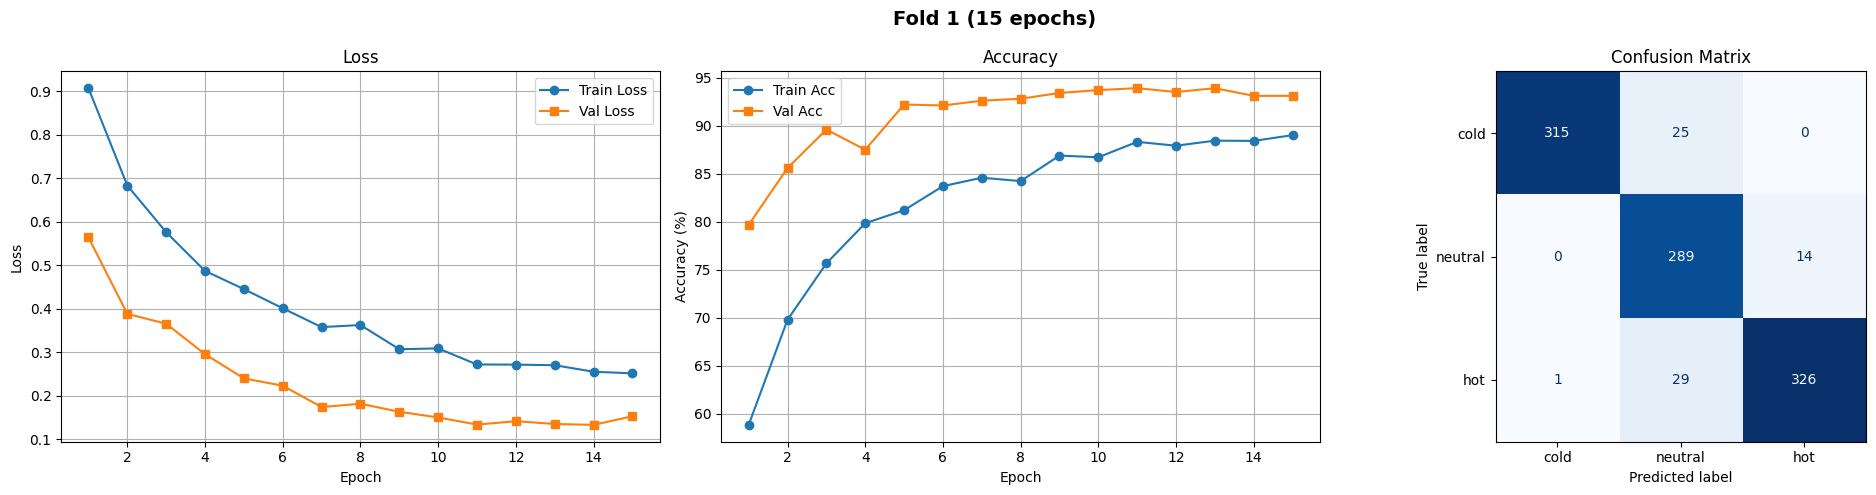

  Fold 1 — best val acc: 93.89% at epoch 11
  Training stopped after 15 epochs



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


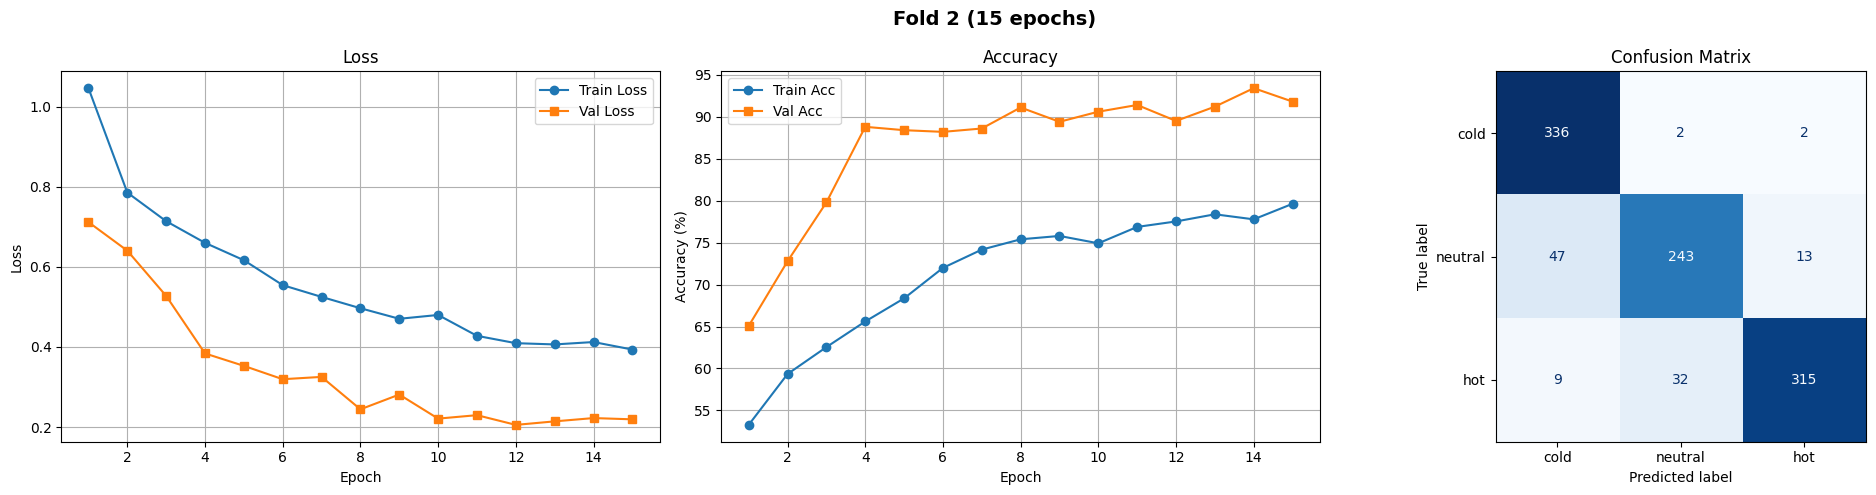

  Fold 2 — best val acc: 93.39% at epoch 14
  Training stopped after 15 epochs



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


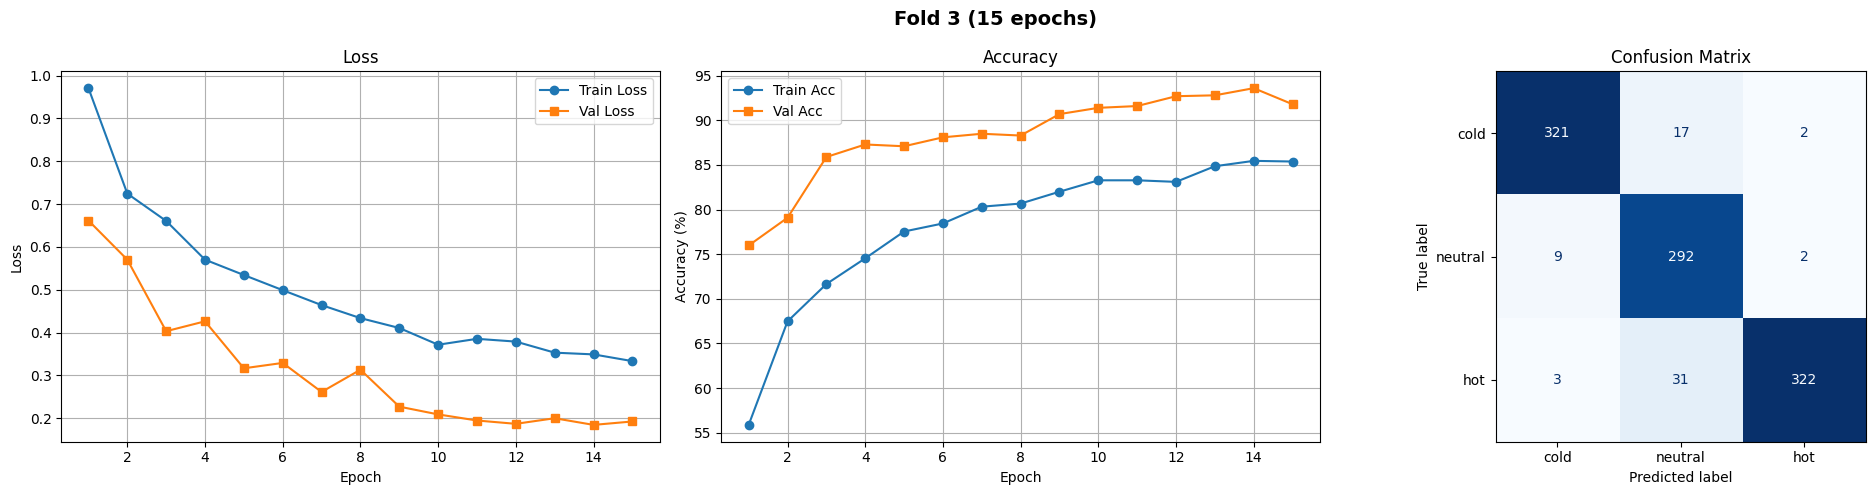

  Fold 3 — best val acc: 93.59% at epoch 14
  Training stopped after 15 epochs



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


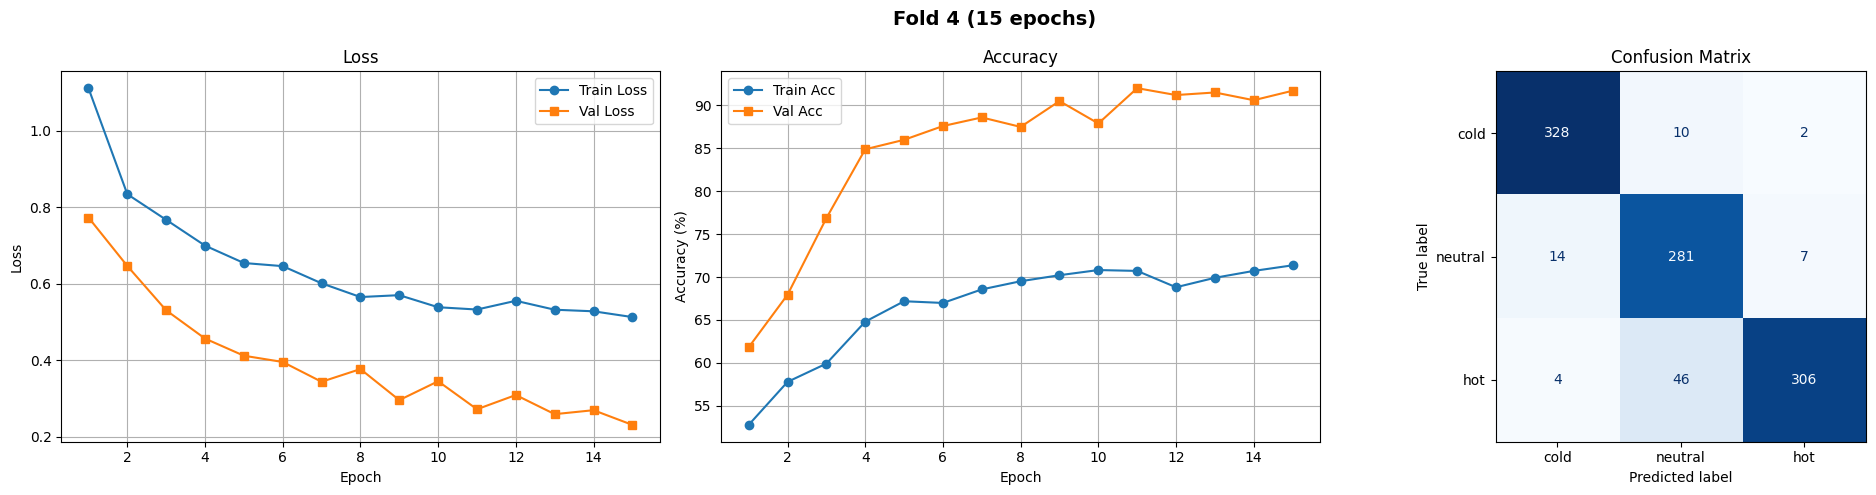

  Fold 4 — best val acc: 91.98% at epoch 11
  Training stopped after 15 epochs



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


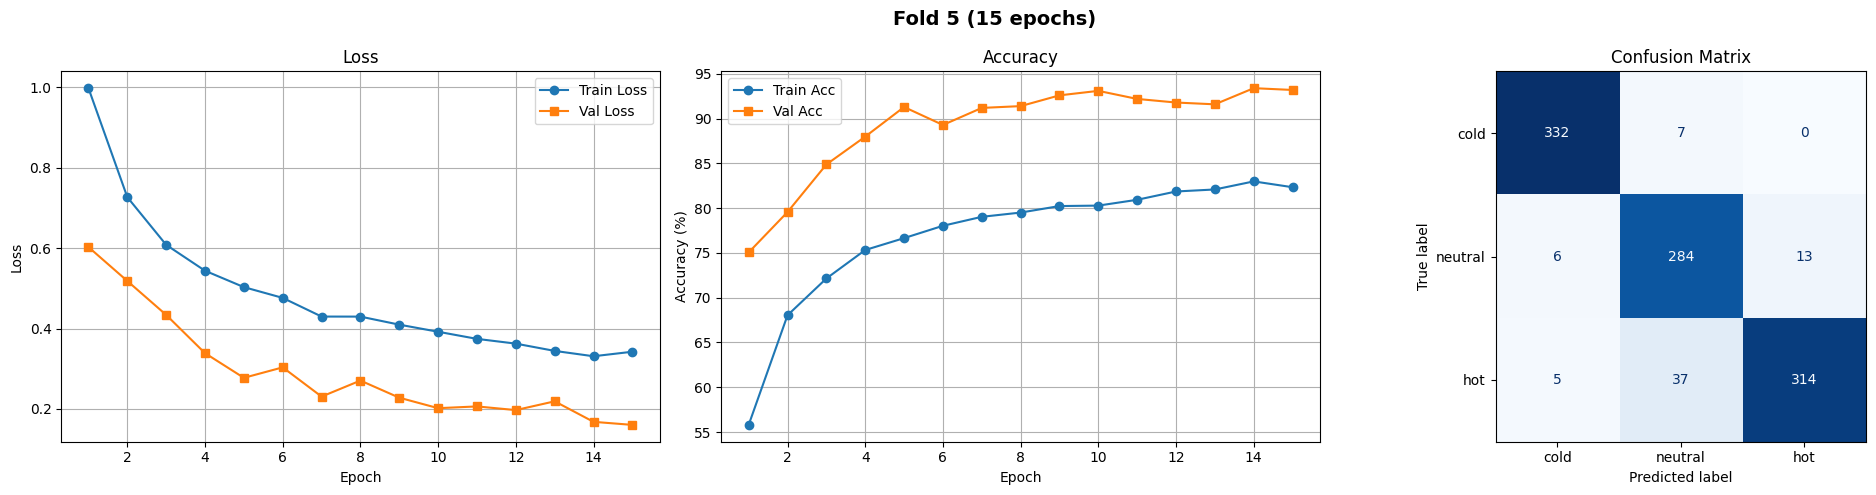

  Fold 5 — best val acc: 93.39% at epoch 14
  Training stopped after 15 epochs

AGGREGATE CONFUSION MATRIX (all folds)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


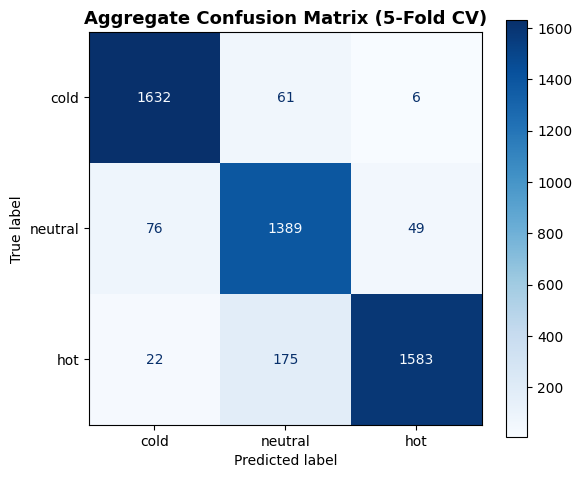


Overall CV accuracy: 92.21%
Mean best-val accuracy: 93.25%
Average epochs run: 15.0


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

CLASS_NAMES = ["cold", "neutral", "hot"]

# ── Per-fold loss / accuracy curves + confusion matrix ───────────────────────
for r in cv_results:
    fold      = r["fold"]
    # Use actual number of epochs run (handles early stopping)
    actual_epochs = len(r["train_losses"])
    epochs    = range(1, actual_epochs + 1)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f"Fold {fold} ({actual_epochs} epochs)", fontsize=14, fontweight="bold")

    # — Loss —
    axes[0].plot(epochs, r["train_losses"], label="Train Loss", marker="o")
    axes[0].plot(epochs, r["val_losses"],   label="Val Loss",   marker="s")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # — Accuracy —
    axes[1].plot(epochs, r["train_accs"], label="Train Acc", marker="o")
    axes[1].plot(epochs, r["val_accs"],   label="Val Acc",   marker="s")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    # — Confusion matrix: run the saved fold model over its val split —
    val_df    = labels_df[labels_df["fold"] == fold]
    
    # Use val transforms if available, otherwise fall back to train transforms
    rgb_trans = val_rgb_transform if 'val_rgb_transform' in dir() else train_rgb_transform
    ir_trans = val_ir_transform if 'val_ir_transform' in dir() else train_ir_transform
    
    val_dset  = PigStressDataset(val_df, RGB_DIR, IR_DIR,
                                 rgb_transform=rgb_trans,
                                 ir_transform=ir_trans,
                                 augment=False)
    val_loader = DataLoader(val_dset, batch_size=params["batch_size"],
                            shuffle=False, num_workers=2)

    fold_model = PigStressModel().to(device)
    fold_model.load_state_dict(torch.load(f"pig_stress_model_fold{fold}.pth",
                                          map_location=device))
    fold_model.eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for rgb_imgs, ir_imgs, labels in val_loader:
            outputs      = fold_model(rgb_imgs.to(device), ir_imgs.to(device))
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=axes[2], colorbar=False, cmap="Blues"
    )
    axes[2].set_title("Confusion Matrix")

    plt.tight_layout()
    plt.show()

    best_epoch = r["val_accs"].index(max(r["val_accs"])) + 1
    print(f"  Fold {fold} — best val acc: {max(r['val_accs']):.2f}% at epoch {best_epoch}")
    print(f"  Training stopped after {actual_epochs} epochs\n")

# ── Aggregate confusion matrix across all folds ───────────────────────────────
print("=" * 60)
print("AGGREGATE CONFUSION MATRIX (all folds)")
print("=" * 60)

# Use val transforms if available, otherwise fall back to train transforms
rgb_trans = val_rgb_transform if 'val_rgb_transform' in dir() else train_rgb_transform
ir_trans = val_ir_transform if 'val_ir_transform' in dir() else train_ir_transform

agg_preds, agg_labels = [], []
for fold in range(1, NUM_FOLDS + 1):
    val_df    = labels_df[labels_df["fold"] == fold]
    val_dset  = PigStressDataset(val_df, RGB_DIR, IR_DIR,
                                 rgb_transform=rgb_trans,
                                 ir_transform=ir_trans,
                                 augment=False)
    val_loader = DataLoader(val_dset, batch_size=params["batch_size"],
                            shuffle=False, num_workers=2)

    fold_model = PigStressModel().to(device)
    fold_model.load_state_dict(torch.load(f"pig_stress_model_fold{fold}.pth",
                                          map_location=device))
    fold_model.eval()

    with torch.no_grad():
        for rgb_imgs, ir_imgs, labels in val_loader:
            outputs      = fold_model(rgb_imgs.to(device), ir_imgs.to(device))
            _, predicted = torch.max(outputs, 1)
            agg_preds.extend(predicted.cpu().numpy())
            agg_labels.extend(labels.numpy())

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(agg_labels, agg_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, colorbar=True, cmap="Blues"
)
ax.set_title("Aggregate Confusion Matrix (5-Fold CV)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

overall_acc = 100 * sum(p == l for p, l in zip(agg_preds, agg_labels)) / len(agg_labels)
print(f"\nOverall CV accuracy: {overall_acc:.2f}%")
print(f"Mean best-val accuracy: {sum(r['best_val_acc'] for r in cv_results)/NUM_FOLDS:.2f}%")
print(f"Average epochs run: {sum(len(r['val_accs']) for r in cv_results)/NUM_FOLDS:.1f}")